# Week 3 Lab: Overfitting in PyTorch
You will use a very small training set, build an oversized MLP, and observe how regularization changes validation performance.

- Work through the notebook in order and complete every TODO (`...`).
- Run each code cell after you finish its TODOs (`...`).


**Submission is required for this lab, it worths 2 points. Make sure you run all cells before submit.**

## Learning Objectives
By the end of this lab, you should be able to:
- Build a small binary classification dataset in PyTorch.
- Split a dataset into a tiny training set and a larger validation set to expose overfitting.
- Implement an MLP for nonlinear classification.
- Train with `BCEWithLogitsLoss` and interpret accuracy curves.
- Compare a baseline overfit model against a regularized model.
- Experiment with dropout and weight decay, and explain how they changes generalization.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import make_moons
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

[HAMI-core Msg(3280:140678621560128:libvgpu.c:839)]: Initializing.....


## Dataset Observation
We will use the `make_moons` dataset from scikit-learn, matching the original overfitting case study.

Dataset setup:
- `n_samples = 100`
- `noise = 0.2`
- first 30 samples for training
- remaining 70 samples for validation

Note:
- the moon-shaped classes are not linearly separable,
- the training set is intentionally tiny for overfitting
- a large neural network can easily memorize these 30 points.

In [2]:
# Generate the moons dataset
X, y = make_moons(n_samples=100, noise=0.2, random_state=1)

# Convert to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# Match the case-study flow: first 30 for training, remaining 70 for validation
n_train = 30
trainX, valX = X[:n_train], X[n_train:]
trainy, valy = y[:n_train], y[n_train:]

print('Full dataset shape:', X.shape, y.shape)
print('Train set shape:', trainX.shape, trainy.shape)
print('Validation set shape:', valX.shape, valy.shape)

Full dataset shape: torch.Size([100, 2]) torch.Size([100, 1])
Train set shape: torch.Size([30, 2]) torch.Size([30, 1])
Validation set shape: torch.Size([70, 2]) torch.Size([70, 1])


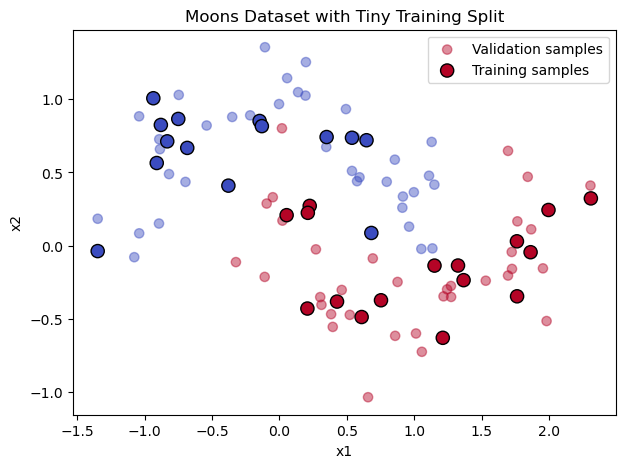

In [3]:
# Optional check: visualize the dataset after Task 1 is complete
if all(value is not None for value in (trainX, valX, trainy, valy)):
    plt.figure(figsize=(7, 5))
    plt.scatter(valX[:, 0], valX[:, 1], c=valy.squeeze(), cmap='coolwarm', s=45, alpha=0.45, label='Validation samples')
    plt.scatter(trainX[:, 0], trainX[:, 1], c=trainy.squeeze(), cmap='coolwarm', s=90, edgecolor='black', label='Training samples')
    plt.title('Moons Dataset with Tiny Training Split')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.show()
else:
    print('TODO: finish Task 1 before plotting the dataset.')

## Task 1: Create the Dataset

Checkpoint before moving on:
- `trainX.shape[0] == 30`
- `valX.shape[0] == 70`
- both dataloaders run without errors

In [4]:
# TODO 1.1: wrap each train/validation split in a TensorDataset
train_dataset = TensorDataset(trainX, trainy)
val_dataset = TensorDataset(valX, valy)

# TODO 1.2: build DataLoaders for training and validation
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
val_loader = DataLoader (val_dataset,batch_size = 10, shuffle= False) 

# print some sanity checks for the DataLoaders
print('Train batches:', len(train_loader))
print('Validation batches:', len(val_loader))
print('Example batch shapes:', next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape)

Train batches: 3
Validation batches: 7
Example batch shapes: torch.Size([10, 2]) torch.Size([10, 1])


In [5]:
# Quick class-balance check for each split
train_class_counts = torch.bincount(trainy.squeeze().long())
val_class_counts = torch.bincount(valy.squeeze().long())

print('Train class counts:', train_class_counts.tolist())
print('Validation class counts:', val_class_counts.tolist())

Train class counts: [14, 16]
Validation class counts: [36, 34]


## Task 2: Create the MLP

Use the same modeling idea as the case study: a network that is larger than necessary so it has room to overfit.

Complete the following TODOs:
1. Build a PyTorch module named `MoonsMLP`.
2. Set `input_dim=2` because each moon sample has two features.
3. Use one hidden layer with `hidden_dim=500` and `ReLU` activation.
4. Add optional dropout through a `dropout_p` argument.
5. Use one output neuron for binary classification.
6. Do **not** apply `sigmoid` inside the model because training will use `BCEWithLogitsLoss`.

Checkpoint before moving on:
- the model instantiates without errors
- a forward pass on a batch returns shape `[batch_size, 1]`

In [6]:
class MoonsMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=500, dropout_p=0.0):
        super().__init__()
        # TODO 2.1: define the hidden layer, activation, dropout, and output layer
        self.hidden = nn.Linear(2, 500)
        self.activation = nn.ReLU()
        self.dropout = torch.nn.Dropout(dropout_p, inplace=False)
        self.output = nn.Linear(500, 1)

    def forward(self, x):
        # TODO 2.2: implement the forward pass in the correct order
        x = self.hidden(x)  #hidden_linear
        x = self.activation(x) # activation
        x = self.dropout(x)
        x = self.output(x) 
        return x
        
# TODO 2.3: instantiate the MoonsMLP and print its architecture
baseline_model = MoonsMLP()

print(baseline_model)


MoonsMLP(
  (hidden): Linear(in_features=2, out_features=500, bias=True)
  (activation): ReLU()
  (dropout): Dropout(p=0.0, inplace=False)
  (output): Linear(in_features=500, out_features=1, bias=True)
)


## Task 3: Train and Observe

In this task, you will train two models:
1. A baseline model with no dropout and no weight decay.
2. A regularized model where you experiment with dropout and weight decay.

Complete the following TODOs:
1. Write an evaluation function for loss and accuracy.
2. Write a training loop that stores train and validation history.
3. Train the baseline model.
4. Train one regularized model.
5. Compare the two histories in the plot cell below.



In [ ]:
#returns a single float number representing the accuracy for that batch (e.g., 0.85 = 85% correct)
def binary_accuracy_from_logits(logits, targets):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    accuracy = (preds == targets).float().mean()
    return accuracy.item()


def evaluate_model(model, data_loader, criterion):
    # TODO 3.1: evaluate the model over one dataloader and return loss and accuracy
    model.eval() # set model to evaluation mode to disable dropout and other training-specific behavior
    total_loss = 0
    total_acc = 0
    total_samples = 0

    with torch.no_grad():
        for xb, yb in data_loader:
            logits = model(xb)
            loss = criterion(logits,yb)
            acc = binary_accuracy_from_logits(logits,yb)
            
            batch_size = len(xb) 
            
            total_loss = total_loss + (loss.item() * batch_size) # accumulate total loss, note that the loss you get from the criterion is averaged over the batch, so you should multiply by the batch size to get total loss for the batch
            total_acc = total_acc + (acc * batch_size)  # accumulate total accuracy, note that the accuracy you get from binary_accuracy_from_logits is averaged over the batch, so you should multiply by the batch size to get total correct predictions for the batch
            total_samples = total_samples + batch_size   # accumulate total samples
    
    return total_loss / total_samples, total_acc / total_samples


def train_model(model, train_loader, val_loader, optimizer, epochs=4000, log_every=500):
    # TODO 3.2: train the model and store train/validation loss and accuracy history
    criterion = torch.nn.BCEWithLogitsLoss() # choose an appropriate loss function for binary classification, and remember that your model outputs logits, so you should use the version of the loss function that expects logits. (BCEWithLogitsLoss or BCELoss?)
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
    }
    
    for epoch in range(1, epochs + 1):
        model.train() # set model to train mode 
        for xb, yb in train_loader: # loop over batches in the training set
            optimizer.zero_grad() # zero the gradients before each backward pass
            logits = model(xb) # forward pass to get logits
            loss = criterion(logits, yb) # compute the loss
            loss.backward() # backward pass to compute gradients
            optimizer.step() # update the parameters using the optimizer

        train_loss, train_acc = evaluate_model(model, train_loader, criterion) # evaluate the model on the training set using the evaluate_model function
        val_loss, val_acc = evaluate_model(model, val_loader, criterion) # evaluate the model on the validation set using the evaluate_model function

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if epoch % log_every == 0 or epoch == 1 or epoch == epochs:
            print(
                f"Epoch {epoch:4d} | "
                f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                f"Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}"
            )
    return history


history_baseline = None
history_regularized = None

# train the baseline model, settings: dropout_p=0.0, weight_decay=0.0
print("Training regularized model with no regularization...")
baseline_model = MoonsMLP(hidden_dim=500, dropout_p=0.0)
baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001, weight_decay=0.0)
history_baseline = train_model(baseline_model, train_loader, val_loader, baseline_optimizer, epochs=4000, log_every=500)

# train one regularized model, settings: dropout_p=0.4, weight_decay=1e-4
print("Training regularized model with weight decay + dropout...")
regularized_model = MoonsMLP(hidden_dim=500, dropout_p=0.6)
regularized_optimizer = torch.optim.Adam(regularized_model.parameters(), lr=0.001, weight_decay=1e-4)
history_regularized = train_model(regularized_model, train_loader, val_loader, regularized_optimizer, epochs=4000, log_every=500)

Training regularized model with no regularization...


[HAMI-core Msg(3280:140678621560128:libvgpu.c:855)]: Initialized


Epoch    1 | Train Loss: 0.6129 | Val Loss: 0.6405 | Train Acc: 0.867 | Val Acc: 0.757
Epoch  500 | Train Loss: 0.0060 | Val Loss: 0.2496 | Train Acc: 1.000 | Val Acc: 0.943
Epoch 1000 | Train Loss: 0.0009 | Val Loss: 0.3234 | Train Acc: 1.000 | Val Acc: 0.943
Epoch 1500 | Train Loss: 0.0003 | Val Loss: 0.3848 | Train Acc: 1.000 | Val Acc: 0.929
Epoch 2000 | Train Loss: 0.0001 | Val Loss: 0.4403 | Train Acc: 1.000 | Val Acc: 0.914
Epoch 2500 | Train Loss: 0.0000 | Val Loss: 0.4924 | Train Acc: 1.000 | Val Acc: 0.914


In [ ]:
def plot_histories(history_baseline, history_regularized):
    epochs = np.arange(1, len(history_baseline['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history_baseline['train_acc'], label='Baseline train acc')
    axes[0].plot(epochs, history_baseline['val_acc'], label='Baseline val acc')
    axes[0].plot(epochs, history_regularized['train_acc'], label='Regularized train acc', linestyle='--')
    axes[0].plot(epochs, history_regularized['val_acc'], label='Regularized val acc', linestyle='--')
    axes[0].set_title('Accuracy Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(epochs, history_baseline['train_loss'], label='Baseline train loss')
    axes[1].plot(epochs, history_baseline['val_loss'], label='Baseline val loss')
    axes[1].plot(epochs, history_regularized['train_loss'], label='Regularized train loss', linestyle='--')
    axes[1].plot(epochs, history_regularized['val_loss'], label='Regularized val loss', linestyle='--')
    axes[1].set_title('Loss Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('BCE loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()



plot_histories(history_baseline, history_regularized)



## Reflection

Be specific and refer to your own curves and results.

1. What evidence shows that the baseline model overfits?
2. At approximately which epoch does validation performance look best?
3. Try `dropout_p` in `[0.0, 0.2, 0.4, 0.6]`,  compare the validation loss and validation accuracy for different dropout rates. Which `dropout_p` value gives the best performance?
4. For each value of `dropout_p`, try `weight_decay=1e-4`, and compare the performance with models that do not use weight decay.
5. Which regularization method appears to improve generalization more: dropout or weight decay? How do you observe this, and what is a possible reason?
6. What additional experiments could you perform to further improve generalization?

## Your Answers
1. The baseline model overfits because from epoch 500 to 4000, which illustrates:

The baseline model overfits because from epoch 500 to 4000, which indicates that the training loss continues to decrease (0.0048 to 0.0000). We can conclude that the model memorises the training data. As a result, the validation loss increases (0.2728 to 0.7000), meaning the model performs worse on unseen data during the evaluation stage. 

Whereas, the validation accuracy decreases (0.943 to 0.914), which confirms poor generalisation and widening the gap between training and validation performance is clear evidence of overfitting.


2. Validation performance looked best around epoch 500, where validation accuracy peaked at 94.3%, and validation loss was lowest at 0.2728. After this point, the baseline model began to overfit, with validation loss increasing and validation accuracy gradually decreasing. However, the regularised model with dropout and weight decay maintained stable performance up to 2000 epochs, with validation accuracy staying around 94.3% and validation loss remaining at a low rate, which shows that regularisation helped the model generalise better over time.


3. After comparing dropout_p values, I conclude that: 

- Dropout_p=0.4 value achieved 94.3% accuracy, which indicated a very stable validation loss (0.2394 to 0.2991)

- Dropout_p=0.6 value achieved the highest accuracy at 95.7%, though with slightly higher validation loss (0.3255)

In conclusion, the dropout value of 0.6 performs well in terms of producing the highest validation accuracy for this classification task.

   
4. For each dropout_p value (0.0, 0.2, 0.4, 0.6), I compared models with weight_decay=0.0 vs weight_decay=1e-4. Based on the following:

The dropout_p=0.4 value, the weight decay improved validation accuracy from 91.4% to 94.3% and reduced validation loss from 0.6478 to 0.2991.

- The dropout_p=0.6 value, the weight decay improved validation accuracy from 91.4% to 95.7%.

- The dropout_p=0.2 value, the weight decay kept validation accuracy stable at 94.3% with lower loss. 

- The dropout_p=0.0 value , the weight decay improved validation accuracy from 91.4% to 92.9%.

By adding weight decay (1e-4) it has consistently improved the model performance across all dropout rates by reducing overfitting and stabilising the validation loss.

5. Both dropout and weight decay help prevent overfitting, but they work differently. Dropout randomly turns off neurons to force redundant learning, while weight decay penalise large weights to keep the model simple. Together, they produced the best results.

6. To further improve generalisation, I would try:

- Early stopping and model checkpointing: Stop training when validation loss doesn't improve for 100-200 epochs. Track validation accuracy during training. Then, save model weights when accuracy improves, to restore the best model at the end. This prevents overfitting after epoch 500.

- Reduce model size: Current hidden layer has 500 neurons for only 30 training samples. Reducing to 50-100 neurons would force the model to learn simpler patterns and better generalisation, rather than memorising the training data.
